In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
league_coeffs = {
    "England Premier League"    : 1.000,
    "Italy Serie A"             : 0.855,
    "Spain La Liga"             : 0.830,
    "Germany Bundesliga"        : 0.760,
    "France Ligue 1"            : 0.640,
    "Netherlands Eredivisie"    : 0.600,
    "Portugal Primeira Liga"    : 0.620,
    "Turkiye Super Lig"         : 0.560,
    "Saudi Arabia Pro League"   : 0.520,
    "Argentina Liga Profesional": 0.500,
    "USA MLS"                   : 0.470,
    "England EFL Championship"  : 0.680,
    "Spain La Liga 2"           : 0.560,
    "Germany 2.Bundesliga"      : 0.540,
    "Italy Serie B"             : 0.530,
    "France Ligue 2"            : 0.440,
}

In [ ]:
FIFA_POINTS = {
    "France"       : 1877.32,
    "England"      : 1825.97,
    "Portugal"     : 1763.83,
    "Brazil"       : 1761.16,
    "Netherlands"  : 1757.87,
    "Belgium"      : 1734.71,
    "Germany"      : 1730.37,
    "Croatia"      : 1717.07,
    "Colombia"     : 1693.09,
    "Senegal"      : 1688.99,
    "United States": 1673.13,
    "Uruguay"      : 1673.07,
    "Japan"        : 1660.43,
    "Switzerland"  : 1649.40,
    "Argentina"    : 1620.00,   
    "Spain"        : 1619.00,   
    "Türkiye"      : 1574.39,   
    "Australia"    : 1507.71,   
    "Algeria"      : 1486.53,   
    "Canada"       : 1430.32,   
    "Norway"       : 1403.80,  
    "Ivory Coast"  : 1397.25,   
    "Sweden"       : 1350.00,  
    "Saudi Arabia" : 1280.00,   
}

In [93]:
ELO_RATINGS = {
    "Spain"        : 2171,
    "Argentina"    : 2113,
    "France"       : 2063,
    "England"      : 2042,
    "Colombia"     : 1998,
    "Brazil"       : 1979,
    "Portugal"     : 1976,
    "Netherlands"  : 1959,
    "Croatia"      : 1933,
    "Norway"       : 1922,
    "Germany"      : 1910,
    "Switzerland"  : 1897,
    "Uruguay"      : 1890,
    "Türkiye"      : 1880,
    "Japan"        : 1879,
    "Senegal"      : 1869,
    "Belgium"      : 1849,
    "United States": 1820,
    "Australia"    : 1750,
    "Algeria"      : 1720,
    "Canada"       : 1700,
    "Ivory Coast"  : 1690,
    "Sweden"       : 1650,
    "Saudi Arabia" : 1550,
}

In [94]:
_fifa_min = min(FIFA_POINTS.values())
_fifa_max = max(FIFA_POINTS.values())
_elo_min  = min(ELO_RATINGS.values())
_elo_max  = max(ELO_RATINGS.values())
 
FIFA_NORM = {k: (v - _fifa_min) / (_fifa_max - _fifa_min) for k, v in FIFA_POINTS.items()}
ELO_NORM  = {k: (v - _elo_min)  / (_elo_max  - _elo_min)  for k, v in ELO_RATINGS.items()}

In [95]:
INTERNATIONAL_STRENGTH = {
    team: 0.5 * FIFA_NORM.get(team, 0.5) + 0.5 * ELO_NORM.get(team, 0.5)
    for team in set(list(FIFA_POINTS.keys()) + list(ELO_RATINGS.keys()))
}

In [96]:
df_pos=pd.read_csv('../../../data/processed/major_leagues/Sofascore_player_data_2526.csv')

C:\Users\vibha\AppData\Local\Temp\ipykernel_29860\14935580.py:1: DtypeWarning: Columns (0: yellowcards) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pos=pd.read_csv('../../../data/processed/major_leagues/Sofascore_player_data_2526.csv')


In [97]:
df_pos_lean = df_pos[['player id', 'position','league']].copy()

In [98]:
df_nation=pd.read_csv('../../../data/raw/matches/wc_roster.csv')

In [99]:
df_nation['player id']=df_nation['player_id']
df_nation=df_nation.drop(columns=['player_id'])

In [100]:
df_nation = pd.merge(df_nation, df_pos_lean, on='player id', how='left')

In [101]:
df_nation.head()

,player_name,team_name,nation,starting_11,player id,position,league
0,Amine Gouiri,Olympique de Marseille,Algeria,1,859026,Forwards,France Ligue 1
1,Aïssa Mandi,Lille,Algeria,1,122810,Defenders,France Ligue 1
2,Farès Chaïbi,Eintracht Frankfurt,Algeria,1,1192318,Midfielders,Germany Bundesliga
3,Houssem Aouar,Al-Ittihad,Algeria,1,846081,Midfielders,Saudi Arabia Pro League
4,Nabil Bentaleb,Lille,Algeria,1,368120,Midfielders,France Ligue 1


In [102]:
nations_to_keep=['France','Portugal','Spain','Germany','Argentina','England','Türkiye','Netherlands',
                 'Switzerland','Belgium','Croatia','United States','Senegal','Ivory Coast','Norway','Brazil',
                 'Saudi Arabia','Sweden','Algeria','Japan','Colombia','Uruguay','Australia','Canada']

In [103]:
df_nation=df_nation[df_nation['nation'].isin(nations_to_keep)]

In [104]:
nation_position_counts = df_nation.pivot_table(
    index='league', 
    columns='position', 
    values='player_name', 
    aggfunc='count', 
    fill_value=0
)

nation_position_counts['Total_Players'] = nation_position_counts.sum(axis=1)

nation_position_counts = nation_position_counts.sort_values(by='Total_Players', ascending=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(nation_position_counts)

position,Defenders,Forwards,Goalkeepers,Midfielders,Total_Players
league,,,,,
England Premier League,40,19,9,50,118
Germany Bundesliga,18,9,5,27,59
Spain La Liga,17,14,3,23,57
Italy Serie A,14,11,2,26,53
France Ligue 1,15,12,7,14,48
Saudi Arabia Pro League,11,6,2,13,32
Turkiye Super Lig,9,1,5,8,23
Netherlands Eredivisie,5,5,0,5,15
USA MLS,2,2,4,7,15


In [105]:
nation_position_counts = df_nation.pivot_table(
    index='nation', 
    columns='position', 
    values='player_name', 
    aggfunc='count', 
    fill_value=0
)

nation_position_counts['Total_Players'] = nation_position_counts.sum(axis=1)

nation_position_counts = nation_position_counts.sort_values(by='Total_Players', ascending=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(nation_position_counts)

position,Defenders,Forwards,Goalkeepers,Midfielders,Total_Players
nation,,,,,
France,9,6,3,8,26
Argentina,8,3,2,11,24
Germany,7,3,3,11,24
Portugal,9,5,2,8,24
Spain,7,5,2,10,24
England,8,7,2,6,23
Netherlands,6,3,3,10,22
Türkiye,7,3,3,9,22
Switzerland,5,3,2,11,21


In [106]:
df_nation=df_nation[['player id','nation','starting_11']]

In [107]:
df_nation.head()

,player id,nation,starting_11
0,859026,Algeria,1
1,122810,Algeria,1
2,1192318,Algeria,1
3,846081,Algeria,1
4,368120,Algeria,1


In [108]:
df_f=pd.read_csv('../../../data/processed/major_leagues/Forwards/EWMA_Major_Forwards_Clustered.csv')
df_m=pd.read_csv('../../../data/processed/major_leagues/Midfielders/EWMA_Major_Midfielders_Clustered.csv')
df_d=pd.read_csv('../../../data/processed/major_leagues/Defenders/EWMA_Major_Defenders_Clustered.csv')
df_g=pd.read_csv('../../../data/processed/major_leagues/Goalkeepers/EWMA_Major_Goalkeepers_Clustered.csv')

In [109]:
df_f = pd.merge(
    df_f,
    df_nation,
    on="player id",
    how="inner"
)

df_m = pd.merge(
    df_m,
    df_nation,
    on="player id",
    how="inner"
)

df_d = pd.merge(
    df_d,
    df_nation,
    on="player id",
    how="inner"
)

df_g = pd.merge(
    df_g,
    df_nation,
    on="player id",
    how="inner"
)

In [110]:
df_g.shape

(45, 69)

In [111]:
f_base = ['goals_per90', 'expectedgoals_per90', 'shotsontarget_per90', 'assists_per90', 'expectedassists_per90', 'keypasses_per90', 'bigchancescreated_per90', 'goals_per_xg', 'goals_minus_xg_per90', 'goalconversionpercentage', 'successfuldribbles_per90', 'defensive_actions', 'aerialduelswonpercentage']
m_base = ['keypasses_per90', 'bigchancescreated_per90', 'expectedassists_per90', 'assists_per90', 'goals_per90', 'expectedgoals_per90', 'shotsontarget_per90', 'touches_per90', 'possessionwonattthird_per90', 'interceptions_per90', 'ballrecovery_per90', 'defensive_actions', 'successfuldribbles_per90']
d_base = ['defensive_actions', 'interceptions_per90', 'clearances_per90', 'tackleswon_per90', 'aerialduelswonpercentage', 'accuratepasses_per90', 'accuratelongballs_per90', 'touches_per90', 'possessionwonattthird_per90', 'groundduelswonpercentage']
g_base = ['saves_per90', 'aerialduelswonpercentage', 'accuratelongballs_per90', 'highclaims_per90']

In [112]:
f_features = [f"{col}_zscore" for col in f_base]
m_features = [f"{col}_zscore" for col in m_base]
d_features = [f"{col}_zscore" for col in d_base]
g_features = [f"{col}_zscore" for col in g_base]

In [ ]:
def calc_weighted_group(df_pos, prefix, feature_list, league_coeffs):
    vectors = {}
 
    for team_name, group in df_pos.groupby("nation"):
 
        # ── Rank-based weights ────────────────────────────────────────────────
        squad_weights = np.where(group["starting_11"] == 1, 1.0, 0.6)
 
        minutes      = group["minutesplayed"].values
        starting_11  = group["starting_11"].values
        rank_weights = np.zeros(len(group))
 
        starter_mask = starting_11 == 1
        if starter_mask.sum() > 0:
            starter_minutes = minutes[starter_mask]
            starter_ranks   = np.argsort(-starter_minutes)
            starter_rw      = np.array([
                max(1.00 - rank * 0.05, 0.20)
                for rank in starter_ranks
            ])
            rank_weights[starter_mask] = starter_rw[np.argsort(starter_ranks)]
 
        bench_mask = starting_11 == 0
        if bench_mask.sum() > 0:
            bench_minutes = minutes[bench_mask]
            bench_ranks   = np.argsort(-bench_minutes)
            bench_rw      = np.array([
                max(0.60 - rank * 0.05, 0.20)
                for rank in bench_ranks
            ])
            rank_weights[bench_mask] = bench_rw[np.argsort(bench_ranks)]
 
        importance_weights = rank_weights * squad_weights
 
        league_multipliers = group["league"].map(league_coeffs).fillna(1.0).values
 

        int_strength = INTERNATIONAL_STRENGTH.get(team_name, 0.5)
 
        team_dict = {
            "meta_count"            : len(group),
            "total_mins"            : group["minutesplayed"].sum(),
            "international_strength": int_strength,
            "fifa_points_norm"      : FIFA_NORM.get(team_name, 0.5),
            "elo_norm"              : ELO_NORM.get(team_name, 0.5),
        }
 
        for col in feature_list:
            if col in group.columns:
                raw_values     = group[col].values
                clipped_values = np.clip(raw_values, -2.5, 2.5)
                taxed_values   = clipped_values * league_multipliers
 
                if importance_weights.sum() > 0:
                    team_dict[f"{prefix}_{col}"] = np.average(
                        taxed_values,
                        weights=importance_weights
                    )
                else:
                    team_dict[f"{prefix}_{col}"] = 0.0
            else:
                team_dict[f"{prefix}_{col}"] = 0.0
 
        vectors[team_name] = team_dict
 
    return vectors

In [114]:
f_profiles=calc_weighted_group(df_f,'f',f_features,league_coeffs)
m_profiles=calc_weighted_group(df_m,'m',m_features,league_coeffs)
d_profiles=calc_weighted_group(df_d,'d',d_features,league_coeffs)
g_profiles=calc_weighted_group(df_g,'g',g_features,league_coeffs)

In [115]:
all_teams = set(list(f_profiles.keys()) + list(m_profiles.keys()) + list(d_profiles.keys()) + list(g_profiles.keys()))

In [116]:
master_rows = []
    
for team in all_teams:

    f = f_profiles.get(team, {f"f_{k}": 0.0 for k in f_features} | {'meta_count': 0, 'total_mins': 0})
    m = m_profiles.get(team, {f"m_{k}": 0.0 for k in m_features} | {'meta_count': 0, 'total_mins': 0})
    d = d_profiles.get(team, {f"d_{k}": 0.0 for k in d_features} | {'meta_count': 0, 'total_mins': 0})
    g = g_profiles.get(team, {f"g_{k}": 0.0 for k in g_features} | {'meta_count': 0, 'total_mins': 0})
    
    row = {'team_name': team}
    

    row.update({k: v for k, v in f.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in m.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in d.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in g.items() if k not in ['meta_count', 'total_mins']})
    

    row['meta_n_forwards'] = f['meta_count']
    row['meta_n_midfielders'] = m['meta_count']
    row['meta_n_defenders'] = d['meta_count']
    row['meta_n_goalkeepers'] = g['meta_count']
    row['meta_total_minutes'] = f['total_mins'] + m['total_mins'] + d['total_mins'] + g['total_mins']
    
    row['eng_attack'] = (f.get('f_expectedgoals_per90_zscore', 0)*0.55 + f.get('f_shotsontarget_per90_zscore', 0)*0.20 + 
                        m.get('m_expectedgoals_per90_zscore', 0)*0.15 + f.get('f_goals_per_xg_zscore', 0)*0.10)
                        
    row['eng_creativity'] = (m.get('m_keypasses_per90_zscore', 0)*0.30 + m.get('m_bigchancescreated_per90_zscore', 0)*0.25 + 
                            f.get('f_bigchancescreated_per90_zscore', 0)*0.20 + m.get('m_expectedassists_per90_zscore', 0)*0.15 + 
                            f.get('f_expectedassists_per90_zscore', 0)*0.10)
                            
    row['eng_defense'] = (d.get('d_defensive_actions_zscore', 0)*0.35 + d.get('d_interceptions_per90_zscore', 0)*0.20 + 
                        d.get('d_clearances_per90_zscore', 0)*0.15 + m.get('m_defensive_actions_zscore', 0)*0.15 + 
                        d.get('d_tackleswon_per90_zscore', 0)*0.15)
                        
    row['eng_pressing'] = (f.get('f_defensive_actions_zscore', 0)*0.35 + m.get('m_possessionwonattthird_per90_zscore', 0)*0.35 + 
                        d.get('d_possessionwonattthird_per90_zscore', 0)*0.30)
                        
    row['eng_buildup'] = (d.get('d_accuratepasses_per90_zscore', 0)*0.30 + m.get('m_touches_per90_zscore', 0)*0.25 + 
                        d.get('d_accuratelongballs_per90_zscore', 0)*0.25 + m.get('m_touches_per90_zscore', 0)*0.20)
                        
    row['eng_aerial'] = (d.get('d_aerialduelswonpercentage_zscore', 0)*0.45 + f.get('f_aerialduelswonpercentage_zscore', 0)*0.30 + 
                        m.get('m_aerialduelswonpercentage_zscore', 0)*0.25)
                        
    row['eng_dribbling'] = (f.get('f_successfuldribbles_per90_zscore', 0)*0.55 + m.get('m_successfuldribbles_per90_zscore', 0)*0.30 + 
                            d.get('d_groundduelswonpercentage_zscore', 0)*0.15)
                            
    row['eng_goalkeeper'] = (g.get('g_saves_per90_zscore', 0)*0.45 + g.get('g_aerialduelswonpercentage_zscore', 0)*0.20 + 
                            g.get('g_accuratelongballs_per90_zscore', 0)*0.20 + g.get('g_highclaims_per90_zscore', 0)*0.15)
                            
    row['eng_finishing'] = (f.get('f_goals_per_xg_zscore', 0)*0.50 + f.get('f_goals_minus_xg_per90_zscore', 0)*0.30 + 
                            f.get('f_goalconversionpercentage_zscore', 0)*0.20)
                            
    row['eng_transition'] = (f.get('f_defensive_actions_zscore', 0)*0.30 + m.get('m_possessionwonattthird_per90_zscore', 0)*0.30 + 
                            f.get('f_successfuldribbles_per90_zscore', 0)*0.25 + m.get('m_ballrecovery_per90_zscore', 0)*0.15)
                            
    master_rows.append(row)
    
nations_stats = pd.DataFrame(master_rows)

In [117]:
nations_stats.shape

(24, 59)

In [118]:
nations_stats.sample(5)

,team_name,international_strength,fifa_points_norm,elo_norm,f_goals_per90_zscore,f_expectedgoals_per90_zscore,f_shotsontarget_per90_zscore,f_assists_per90_zscore,f_expectedassists_per90_zscore,f_keypasses_per90_zscore,...,eng_attack,eng_creativity,eng_defense,eng_pressing,eng_buildup,eng_aerial,eng_dribbling,eng_goalkeeper,eng_finishing,eng_transition
23,Norway,0.403146,0.207259,0.599034,1.360705,1.169541,1.332331,0.070858,-0.336824,-0.500553,...,0.917893,0.242804,-0.196818,-0.136336,-0.066571,0.597932,-0.200276,0.274214,0.509704,-0.142196
12,Spain,0.783767,0.567535,1.000000,0.267391,0.155472,0.129835,0.211408,0.344287,0.296007,...,0.217485,0.716042,0.108232,0.454379,0.740740,0.042182,0.170718,-0.318458,0.257120,0.392248
22,Netherlands,0.729319,0.800023,0.658615,0.908597,0.958604,0.686186,-0.058255,0.029229,-0.072908,...,0.783231,0.183271,0.086319,-0.084556,0.541269,0.467120,-0.131642,0.096279,0.247105,-0.293291
1,Switzerland,0.588603,0.618429,0.558776,0.206284,0.190455,-0.058179,-0.123082,-0.292575,-0.205201,...,0.070840,-0.152903,-0.026537,-0.167393,0.211642,0.141267,0.057941,-0.423025,0.143090,0.017751
10,Japan,0.583343,0.636895,0.529791,1.062938,0.914293,0.594959,-0.402662,-0.517007,-0.493817,...,0.661066,-0.018101,-0.265705,-0.081292,-0.074097,0.175048,-0.164502,0.750449,0.437966,-0.246459


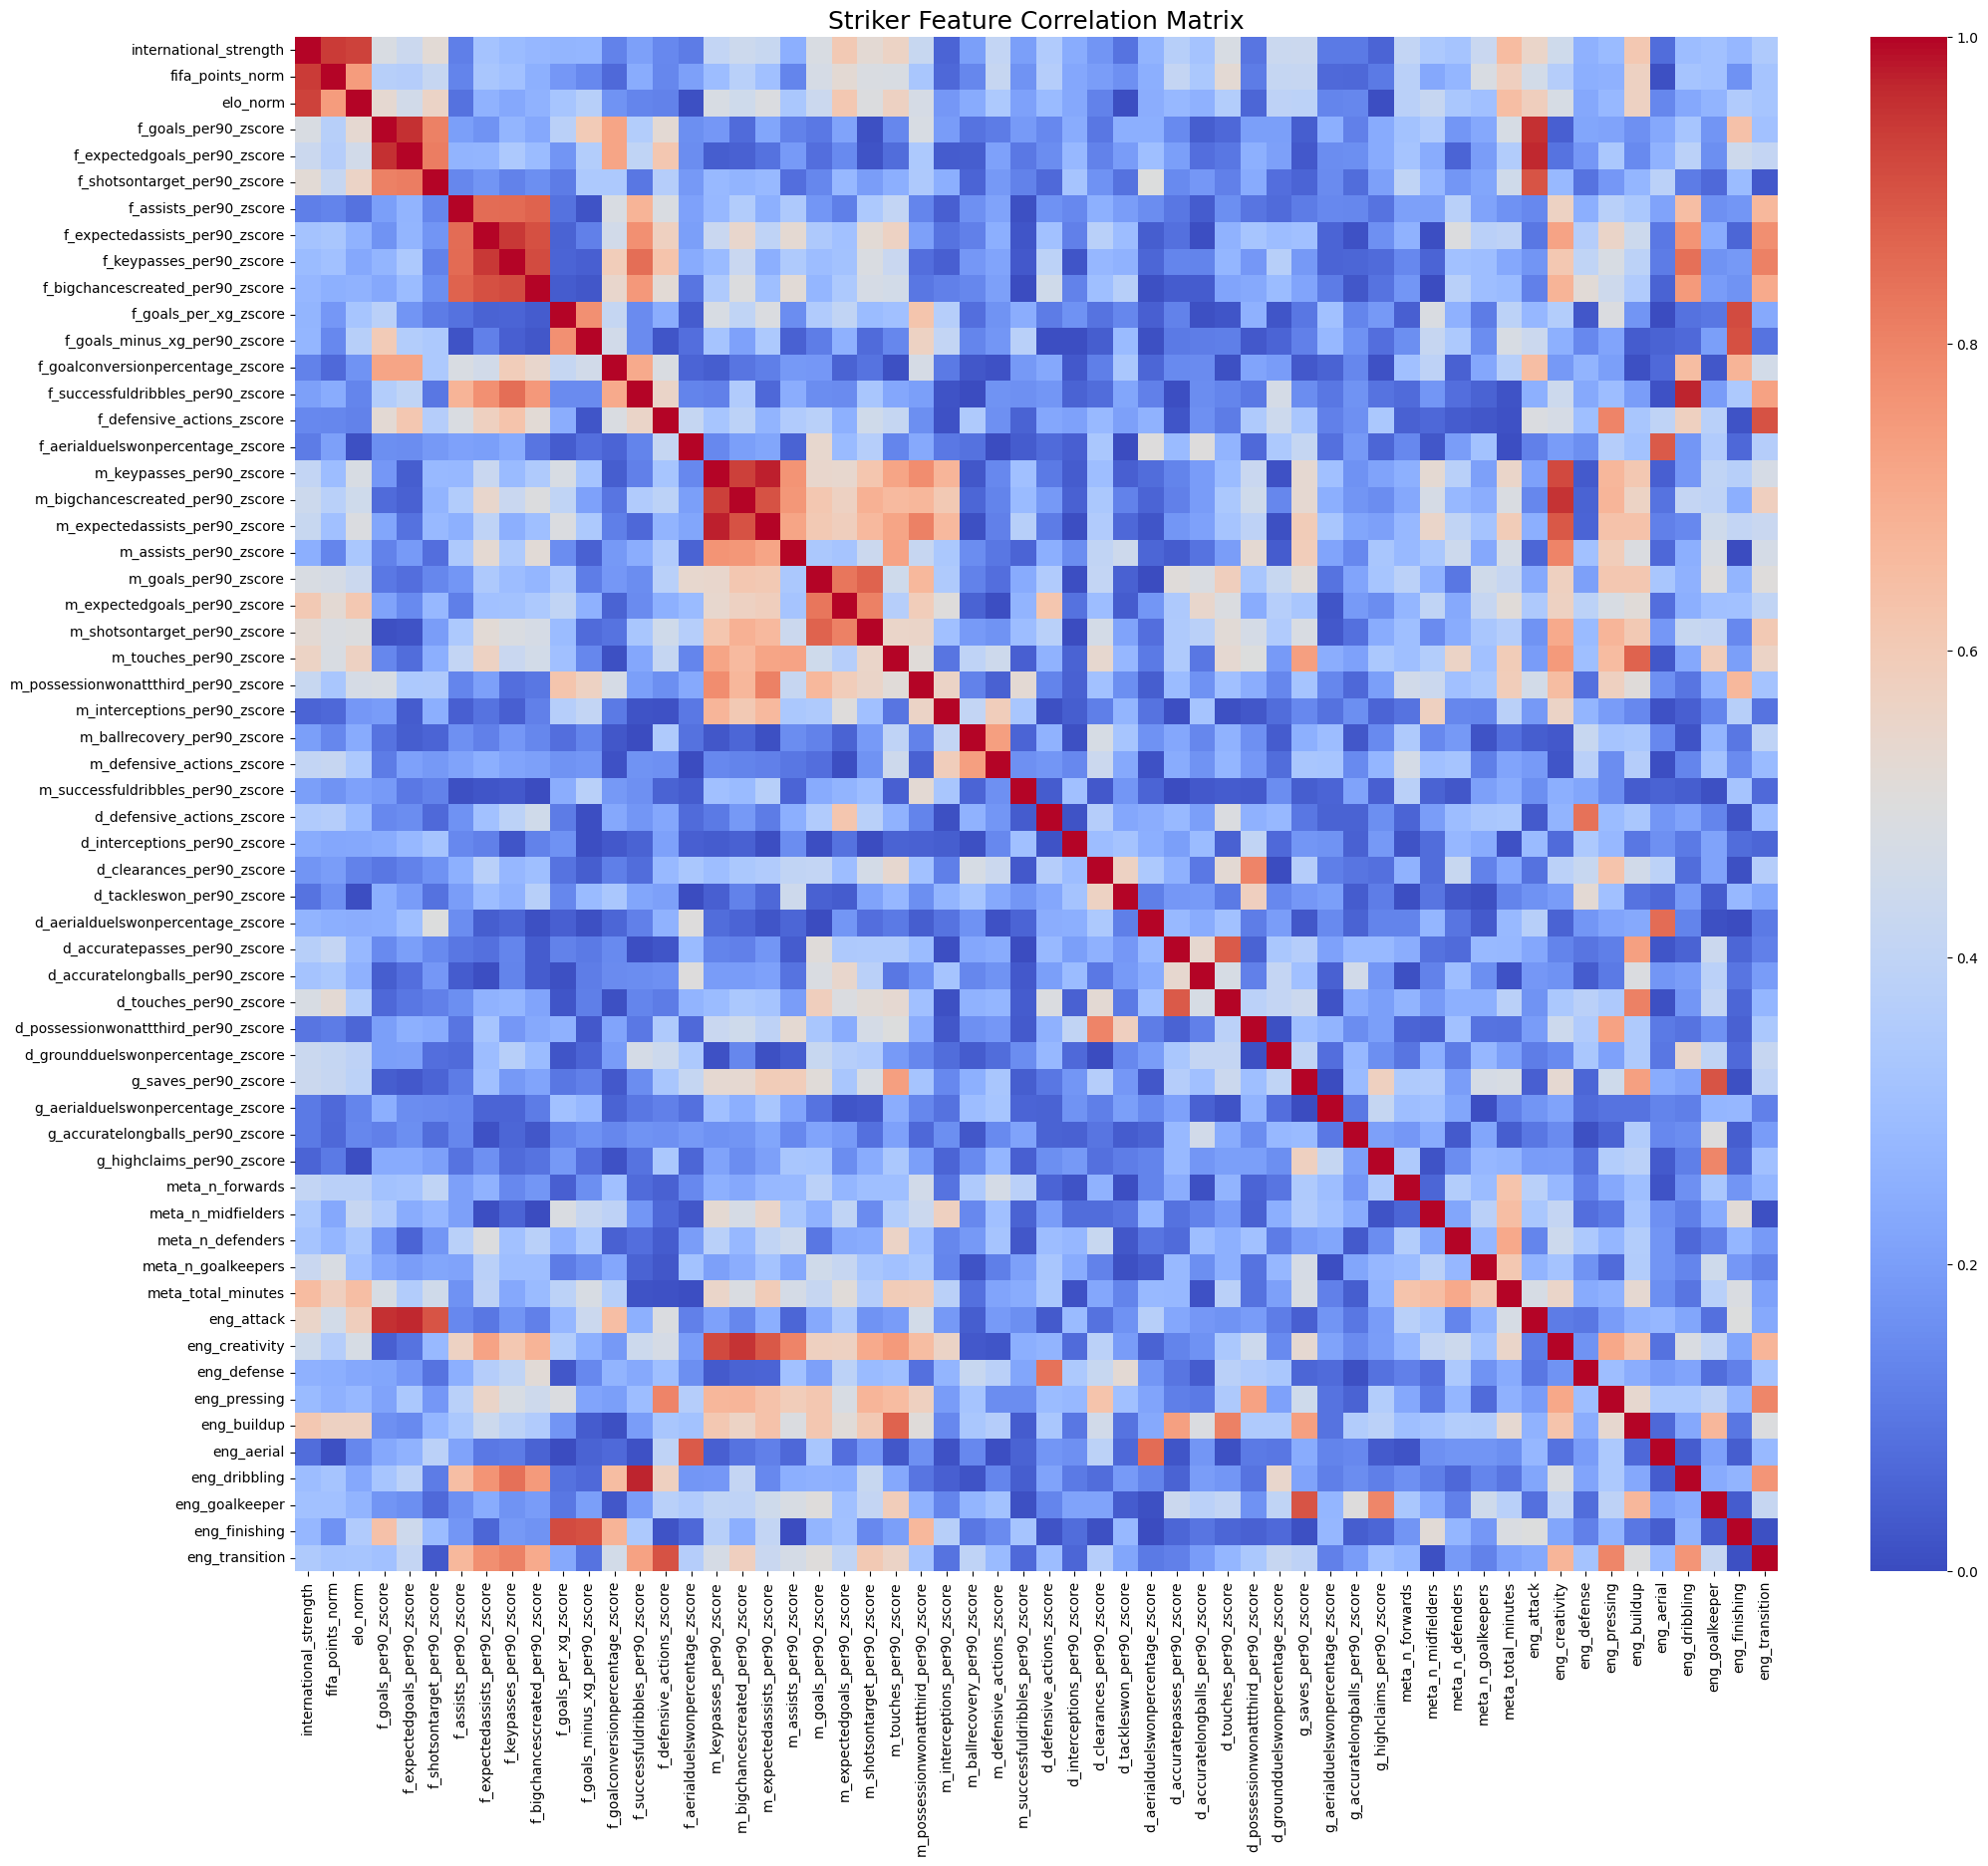

In [119]:
corr_matrix = nations_stats.drop(columns=['team_name' ]).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [120]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,m_keypasses_per90_zscore,m_expectedassists_per90_zscore,0.973333
1,f_successfuldribbles_per90_zscore,eng_dribbling,0.971836
2,f_expectedgoals_per90_zscore,eng_attack,0.967713
3,f_goals_per90_zscore,eng_attack,0.955262
4,f_goals_per90_zscore,f_expectedgoals_per90_zscore,0.954083
5,m_bigchancescreated_per90_zscore,eng_creativity,0.949424
6,f_expectedassists_per90_zscore,f_keypasses_per90_zscore,0.942565
7,international_strength,fifa_points_norm,0.939712
8,m_keypasses_per90_zscore,m_bigchancescreated_per90_zscore,0.930804
9,international_strength,elo_norm,0.927669


In [121]:
drops = [
    'f_expectedgoals_per90_zscore',
    'f_goals_per_xg_zscore',
    'f_successfuldribbles_per90_zscore',
    'f_goals_minus_xg_per90_zscore',
    'f_shotsontarget_per90_zscore',
    'f_goals_per90_zscore',
    'd_accuratepasses_per90_zscore',
    'm_touches_per90_zscore',
    'd_touches_per90_zscore',
    'm_bigchancescreated_per90_zscore',
    'm_keypasses_per90_zscore',
    'g_saves_per90_zscore',
    'm_expectedassists_per90_zscore',
    'm_assists_per90_zscore',
    'm_expectedgoals_per90_zscore',
    'm_goals_per90_zscore',
    'f_expectedassists_per90_zscore'
]

nations_stats=nations_stats.drop(columns=drops)

In [122]:
nation_to_id = {
    nation: idx
    for idx, nation in enumerate(sorted(df_nation["nation"].unique()), start=1)
}

In [123]:
nations_stats["team_id"] = nations_stats["team_name"].map(nation_to_id)

In [124]:
nations_stats.head(15)

,team_name,international_strength,fifa_points_norm,elo_norm,f_assists_per90_zscore,f_keypasses_per90_zscore,f_bigchancescreated_per90_zscore,f_goalconversionpercentage_zscore,f_defensive_actions_zscore,f_aerialduelswonpercentage_zscore,...,eng_creativity,eng_defense,eng_pressing,eng_buildup,eng_aerial,eng_dribbling,eng_goalkeeper,eng_finishing,eng_transition,team_id
0,Ivory Coast,0.210868,0.196293,0.225443,0.638245,0.247428,0.271137,-0.130756,-0.045050,0.358579,...,0.018975,0.043937,-0.042728,0.140520,0.168898,0.060500,0.194168,-0.209755,0.053908,12
1,Switzerland,0.588603,0.618429,0.558776,-0.123082,-0.205201,-0.120204,0.456581,0.129910,0.365306,...,-0.152903,-0.026537,-0.167393,0.211642,0.141267,0.057941,-0.423025,0.143090,0.017751,21
2,Belgium,0.621366,0.761250,0.481481,1.018065,0.835566,0.973218,-0.178642,0.876300,-0.578801,...,0.799457,-0.055391,0.521552,0.373854,-0.399507,0.447233,-0.233881,0.227385,0.476574,4
3,France,0.913043,1.000000,0.826087,0.650695,0.705035,0.608761,0.615867,-0.157628,0.686750,...,0.313819,0.146847,0.113057,0.688726,0.415783,0.436436,0.030057,0.506138,0.296176,10
4,Senegal,0.599198,0.684708,0.513688,-0.186733,0.001297,0.021084,0.348939,0.026972,0.001217,...,-0.210966,0.135783,-0.080416,0.079514,0.159754,0.072016,-0.130559,-0.019320,0.034296,18
5,Brazil,0.748176,0.805531,0.690821,0.715850,0.955631,0.566522,0.068840,0.991272,-1.092166,...,0.657108,-0.142963,0.433448,0.884839,-0.200384,0.878485,-0.671857,0.190517,0.770524,5
6,United States,0.546470,0.658156,0.434783,0.462840,0.349668,0.424843,0.455394,0.005497,-0.272058,...,0.127030,0.123065,-0.062484,0.051848,-0.073434,0.018554,0.634753,0.117648,0.044343,23
7,Saudi Arabia,0.000000,0.000000,0.000000,0.115165,-0.173123,0.097574,0.456386,0.466877,0.472411,...,0.174381,0.143367,0.401255,0.241516,0.185621,-0.185312,-0.105794,0.427611,0.131200,17
8,Türkiye,0.512126,0.492851,0.531401,0.638371,1.123257,0.891065,0.043126,0.822102,0.234289,...,0.916876,0.104370,0.631580,0.420909,0.143253,0.417370,-0.072173,0.238486,0.636129,22
9,Croatia,0.674233,0.731718,0.616747,0.238263,0.229380,-0.062441,0.545245,0.640829,0.147360,...,0.357130,-0.001339,0.450145,0.676583,0.218705,-0.149852,0.329086,0.326260,0.355856,8


In [125]:
nations_stats.to_csv('../../../data/processed/Teams/World_Cup_Nations_26.csv',index=False)